- Normalising Pixel Values for Consistent Brightness

In [2]:
import cv2
img = cv2.imread (r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg')
normalized = img / 255.0

- Histogram Equalization

In [4]:
# Load the image
img = cv2.imread(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg')

# Convert the image to grayscale
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply histogram equalization to the grayscale image
eq_img = cv2.equalizeHist(gray_img)

(-0.5, 343.5, 225.5, -0.5)

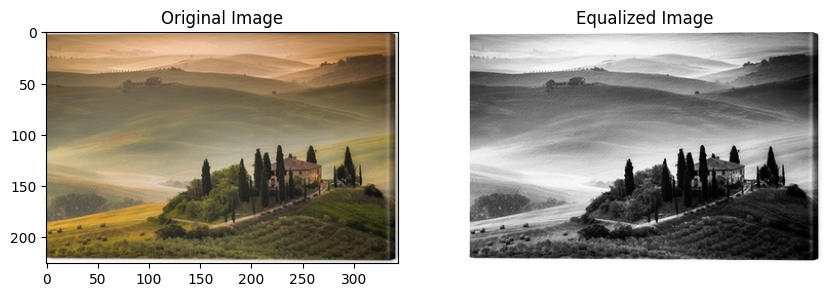

In [5]:
import cv2
import matplotlib.pyplot as plt

# Display the original and equalized images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for matplotlib
plt.title('Original Image')
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(eq_img, cv2.COLOR_BGR2RGB))
plt.title('Equalized Image')
plt.axis('off')



- preprocess_image function: This function encapsulates the preprocessing steps.
- Load image:
  cv2.imread(image_path) loads the image from the specified path.
Resize:
  cv2.resize(img, target_size) resizes the image to the desired target_size. This is important for consistency in input dimensions for ML/DL models.
**Convert to grayscale** (optional):
  cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) converts the image to grayscale. This might be needed for some tasks where color information is not relevant or to reduce dimensionality. However, you should consider if color information is important for the problem you are trying to solve and skip this if necessary.
- Normalization:
  img = img / 255.0 normalizes pixel values to the range [0, 1]. This is a common practice in deep learning to improve model training.

In [3]:
import cv2
import numpy as np

def preprocess_image(image_path, target_size=(224, 224)):

    # Load the image
    img = cv2.imread(image_path)

    # Resize the image
    img = cv2.resize(img, target_size)

    # Convert to grayscale (optional for some tasks)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Normalize pixel values to the range [0, 1]
    img = img / 255.0

    # Data augmentation (optional)
    # ... (apply transformations like rotation, flipping, etc.)

    # Return the preprocessed image
    return img

# Example usage
image_path = r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg'
preprocessed_image = preprocess_image(image_path)



**Applying Filters to Reduce Noise and Sharpen Images**

**Noise Reduction**

In [4]:
import numpy as np

def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

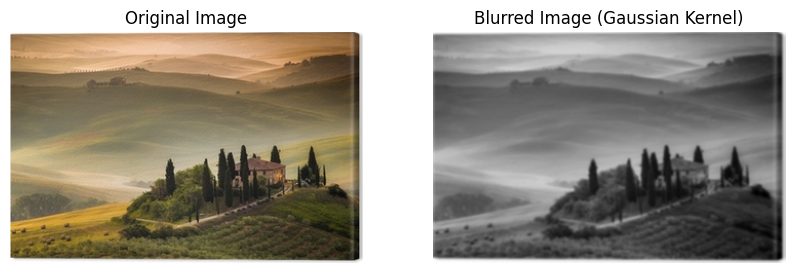

In [6]:
import cv2
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread(image_path)

# Load an image
image_path = r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg'
image = cv2.imread(image_path)

# Convert image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Get the Gaussian kernel with size 5x5 and sigma=1
kernel = gaussian_kernel(size=5, sigma=1)

# Apply the Gaussian kernel to the image using cv2.filter2D
blurred_image = cv2.filter2D(gray_image, -1, kernel)

# Display the original and blurred images
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Blurred image
plt.subplot(1, 2, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Blurred Image (Gaussian Kernel)')
plt.axis('off')

plt.show()

**Sobel, Prewitt, Canny filters for edge detection**

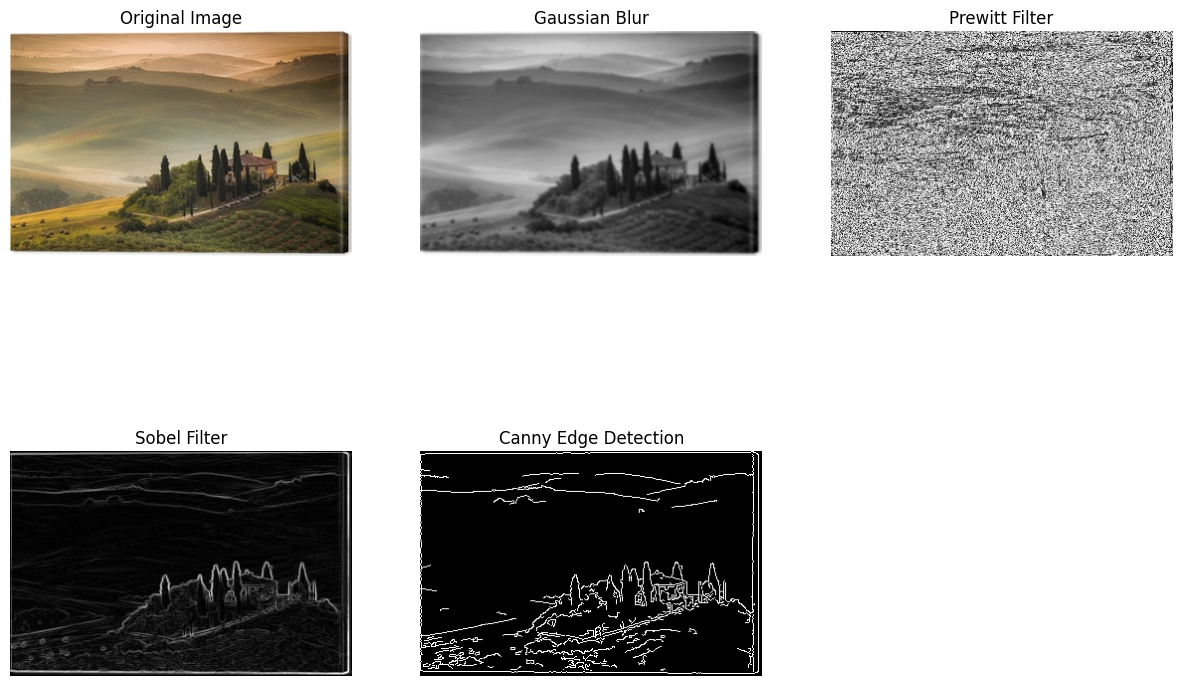

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

# Define the Gaussian kernel function
def gaussian_kernel(size, sigma=1):
    size = int(size) // 2
    x, y = np.mgrid[-size:size+1, -size:size+1]
    normal = 1 / (2.0 * np.pi * sigma**2)
    g =  np.exp(-((x**2 + y**2) / (2.0*sigma**2))) * normal
    return g

# Load an image
image_path = r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg'
image = cv2.imread(image_path)

# Convert image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian Blur
kernel = gaussian_kernel(size=5, sigma=1)
blurred_image = cv2.filter2D(gray_image, -1, kernel)

# Apply Prewitt filter
prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
prewitt_image_x = ndimage.convolve(gray_image, prewitt_x)
prewitt_image_y = ndimage.convolve(gray_image, prewitt_y)
prewitt_image = np.sqrt(prewitt_image_x**2 + prewitt_image_y**2)

# Apply Sobel filter
sobel_x = cv2.Sobel(gray_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_image = np.sqrt(sobel_x**2 + sobel_y**2)

# Apply Canny Edge Detection
canny_image = cv2.Canny(gray_image, 100, 200)

# Display the original image and processed images
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Blurred image (Gaussian)
plt.subplot(2, 3, 2)
plt.imshow(blurred_image, cmap='gray')
plt.title('Gaussian Blur')
plt.axis('off')

# Prewitt filter
plt.subplot(2, 3, 3)
plt.imshow(prewitt_image, cmap='gray')
plt.title('Prewitt Filter')
plt.axis('off')

# Sobel filter
plt.subplot(2, 3, 4)
plt.imshow(sobel_image, cmap='gray')
plt.title('Sobel Filter')
plt.axis('off')

# Canny edge detection
plt.subplot(2, 3, 5)
plt.imshow(canny_image, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()


**Emma Contouring**

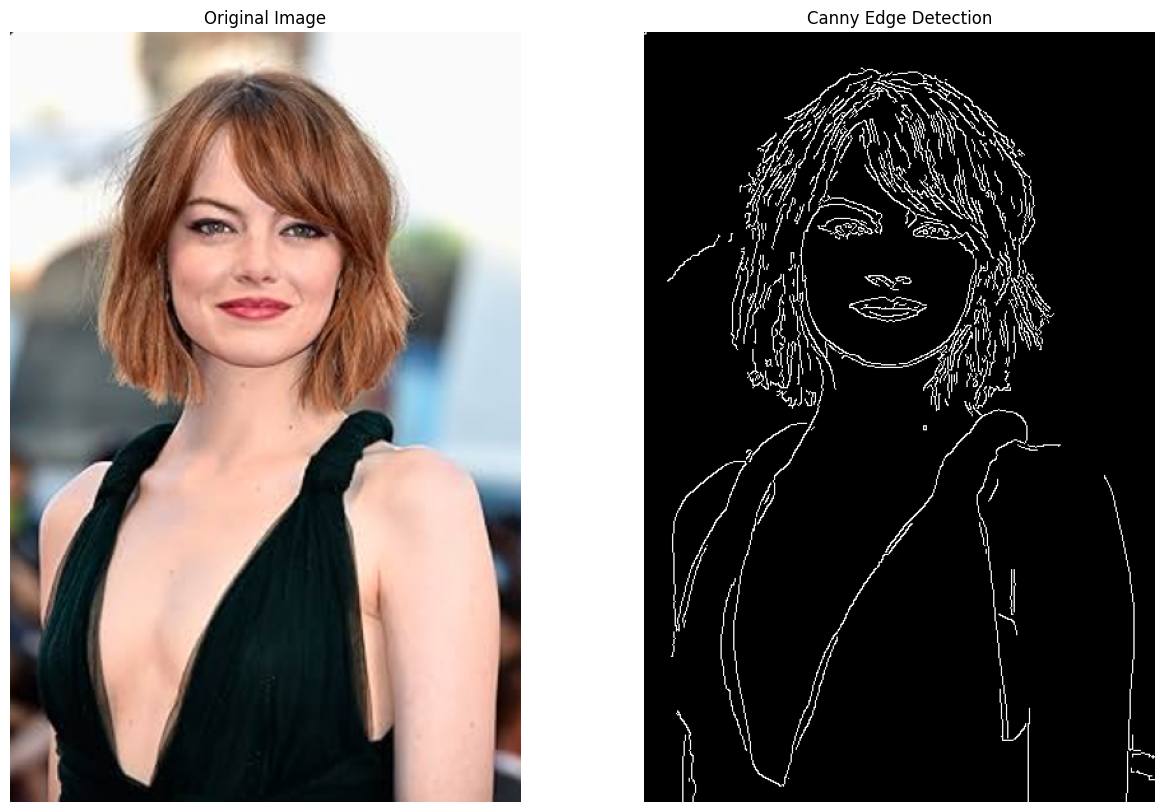

In [10]:
# Load an image
image_path = r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\Emma_Stone.png'
image = cv2.imread(image_path)

# Convert image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Canny Edge Detection
canny_image = cv2.Canny(gray_image, 100, 200)

# Display the original image and processed images
plt.figure(figsize=(15, 10))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')


# Canny edge detection
plt.subplot(1, 2, 2)
plt.imshow(canny_image, cmap='gray')
plt.title('Canny Edge Detection')
plt.axis('off')

plt.show()

**Convolution Filters**

- Explanation of Steps:
- Load the image: We read the image from the provided path and convert it to grayscale for simplicity.
- Define the sharpening kernel: The kernel matrix sharpens the image by increasing the intensity of edges.
- Apply the convolution: We use the filter2D() function in OpenCV to apply the sharpening kernel to the image.
Display: We plot the original and sharpened images for comparison.

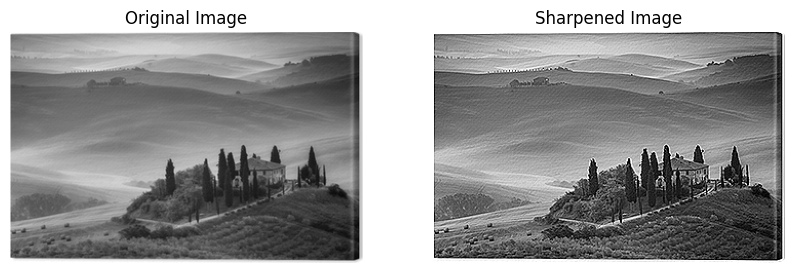

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load the image
image_path = r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\tableaux-sur-toile-toscane-paysage-italien.jpg'
image = cv2.imread(image_path)

# Convert the image to grayscale for simplicity
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Step 2: Define the sharpening kernel
sharpening_kernel = np.array([[0, -1, 0],
                              [-1, 5, -1],
                              [0, -1, 0]])

# Step 3: Apply the convolution using the sharpening kernel
sharpened_image = cv2.filter2D(gray_image, -1, sharpening_kernel)

# Step 4: Display the original and sharpened images side by side
plt.figure(figsize=(10, 5))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

# Sharpened image
plt.subplot(1, 2, 2)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')
plt.axis('off')

# Show the images
plt.show()


**HOG Features descriptor**

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load the image
img = cv2.imread(r'C:\Users\Kered\ML_DVRC_2025\Lecture8\TD\Emma_Stone.png')

# Convert the original image to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert the original image to gray scale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Specify the parameters for our HOG descriptor
# Adjust win_size to be divisible by block_stride
win_size = (img_gray.shape[1] - img_gray.shape[1] % 8, img_gray.shape[0] - img_gray.shape[0] % 8) #changed here
cell_size = (8, 8)
block_size = (16, 16)
block_stride = (8, 8)
num_bins = 9

# Set the parameters of the HOG descriptor using the variables defined above
hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

# Resize the image to match win_size
img_gray = cv2.resize(img_gray, win_size) #added to ensure the image size matches win_size


# Compute the HOG Descriptor for the gray scale image
hog_descriptor = hog.compute(img_gray)

print ('HOG Descriptor:', hog_descriptor)
print ('HOG Descriptor has shape:', hog_descriptor.shape)

HOG Descriptor: [0.45147872 0.42134824 0.45147872 ... 0.2269085  0.14363043 0.27589145]
HOG Descriptor has shape: (130536,)


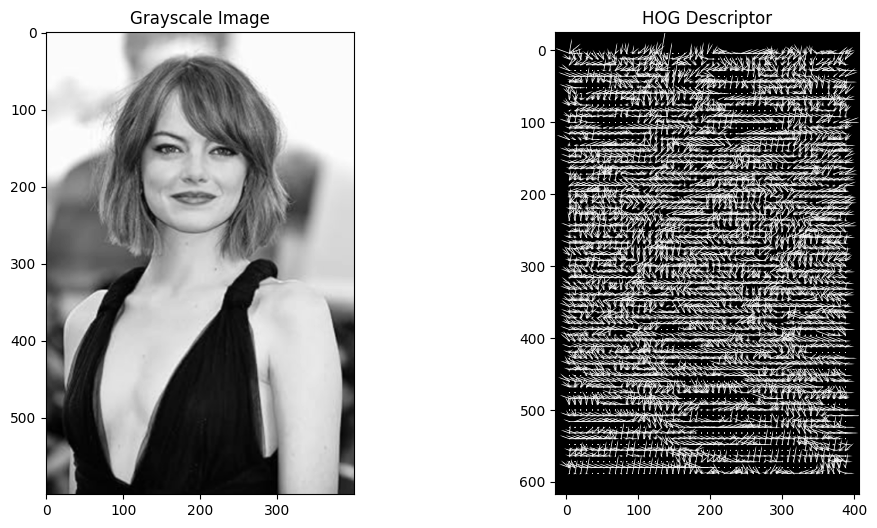

In [13]:
# Reshape the feature vector to [number of blocks in x and y direction, number of cells per block in x and y direction, number of bins]
# This will be useful later when we plot the feature vector, so that the feature vector indexing matches the image indexing
# Reshape the feature vector to [number of blocks in x and y direction, number of cells per block in x and y direction, number of bins]
# This will be useful later when we plot the feature vector, so that the feature vector indexing matches the image indexing
# Calculate the correct dimensions based on the HOG parameters and image size
# Calculate the correct dimensions based on the HOG parameters and image size
n_blocks_x = (img_gray.shape[1] // cell_size[1]) - (block_size[1] // cell_size[1]) + 1
n_blocks_y = (img_gray.shape[0] // cell_size[0]) - (block_size[0] // cell_size[0]) + 1
hog_descriptor_reshaped = hog_descriptor.reshape(n_blocks_y,  # Number of blocks in y direction
                                                 n_blocks_x,  # Number of blocks in x direction
                                                 block_size[0] // cell_size[0],  # Number of cells per block in y direction
                                                 block_size[1] // cell_size[1],  # Number of cells per block in x direction
                                                 num_bins).transpose((1, 0, 2, 3, 4))


# Create an array that will hold the average gradients for each cell
ave_grad = np.zeros((n_blocks_y, n_blocks_x, num_bins)) # Update shape based on the calculated dimensions

# Create an array that will count the number of histograms per cell
hist_counter = np.zeros((n_blocks_y, n_blocks_x, 1)) # Update shape based on the calculated dimensions


# Add up all the histograms for each cell and count the number of histograms per cell
# Iterate through the blocks in the HOG descriptor
for i in range(hog_descriptor_reshaped.shape[0]): # i iterates through the first dimension (49)
    for j in range(hog_descriptor_reshaped.shape[1]): # j iterates through the second dimension (74)
        # Swap i and j when indexing ave_grad to align with its shape
        ave_grad[j, i] += hog_descriptor_reshaped[i, j, 0, 0]  # Sum the histograms for the current cell

        hist_counter[j, i] += 1  # Increment the histogram count for the current cell

# Calculate the average gradient for each cell
ave_grad /= hist_counter

# Calculate the total number of vectors we have in all the cells.
len_vecs = ave_grad.shape[0] * ave_grad.shape[1] * ave_grad.shape[2]

# Create an array that has num_bins equally spaced between 0 and 180 degress in radians.
deg = np.linspace(0, np.pi, num_bins, endpoint=False)

# Each cell will have a histogram with num_bins. For each cell, plot each bin as a vector (with its magnitude
# equal to the height of the bin in the histogram, and its angle corresponding to the bin in the histogram).
# To do this, create rank 1 arrays that will hold the (x,y)-coordinate of all the vectors in all the cells in the
# image. Also, create the rank 1 arrays that will hold all the (U,V)-components of all the vectors in all the
# cells in the image. Create the arrays that will hold all the vector positons and components.
U = np.zeros((len_vecs))
V = np.zeros((len_vecs))
X = np.zeros((len_vecs))
Y = np.zeros((len_vecs))

# Set the counter to zero
counter = 0

# Use the cosine and sine functions to calculate the vector components (U,V) from their maginitudes. Remember the
# cosine and sine functions take angles in radians. Calculate the vector positions and magnitudes from the
# average gradient array
for i in range(ave_grad.shape[0]):
    for j in range(ave_grad.shape[1]):
        for k in range(ave_grad.shape[2]):
            U[counter] = ave_grad[i, j, k] * np.cos(deg[k])
            V[counter] = ave_grad[i, j, k] * np.sin(deg[k])

            X[counter] = (cell_size[0] / 2) + (cell_size[0] * i)
            Y[counter] = (cell_size[1] / 2) + (cell_size[1] * j)

            counter = counter + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Display the image
ax1.set(title='Grayscale Image')
ax1.imshow(img_gray, cmap='gray')

# Plot the feature vector (HOG Descriptor)
ax2.set(title='HOG Descriptor')
ax2.quiver(Y, X, U, V, color='white', headwidth=0, headlength=0, scale_units='inches', scale=3)
ax2.invert_yaxis()
ax2.set_aspect(aspect=1)
ax2.set_facecolor('black')